In [1]:
import torch
import time
import warnings
import os

from device import setup_device
from utk_dataset import UTKFaceDataset
from model import Encoder
from loss import *
from train_encoder import *
from visualization import *

In [2]:
warnings.filterwarnings("ignore", message=".*force_all_finite.*")

from numba.core.errors import NumbaWarning
warnings.filterwarnings("ignore", category=NumbaWarning)

warnings.filterwarnings("ignore", message=".*verbose parameter is deprecated.*")

In [3]:
verbose=True

In [4]:
device, data_parallel = setup_device(use_gpu_1_only=False, verbose=verbose)

[00:30:19] [INFO] ✅ CUDA is available: 2 GPU(s) visible


In [5]:
backbone_model = 'resnet50'
pretrained = True
model = Encoder(backbone_name=backbone_model, pretrained=pretrained)
model = data_parallel(model).to(device)

[00:30:19] [INFO] 🚀 Wrapping model in DataParallel over 2 GPUs


In [6]:
test_dir = './outputs/current/initial_test'
best_model_file = 'best_model.pth'

monitor_config = {
    'mode': 'max',
    'key_metric': 'kendall', #'train_loss',
    'base_dir': test_dir,
    'best_model_file': os.path.join(test_dir, best_model_file),
    'save_analysis': True,
    'early_stopping': True,
    'patience': 10,
    'delta': 1e-4
}

config = {
    'device': device,
    'data_folder': './data/utkface/UTKFace',
    'model': model
}

train_config = {
    'batch_size': 256,
    'num_epochs': 2,
    'learning_rate': 1e-3,
    'temperature': 0.5,
    'augmentations': 'crop,flip,color,grayscale',
    'train_size': 0.8,
    'metrics': [
        "val_loss",
        "embedding_norm",
        "embedding_variance",
        "knn_accuracy",
        "spearman",
        "kendall",
        "grad_norm",
        "lr"
    ],
    'monitor_config': monitor_config
}

vis_config = {
    'best_model_path': monitor_config['best_model_file'],
    'fig_size': 5
}

In [7]:
start_time = time.time()
train_encoder({**config, **train_config}, verbose=verbose)
end_time = time.time()
print_verbose(f"Training completed in: {end_time - start_time:.2f} seconds", verbose)

[00:30:19] [INFO] Configuration check passed: 10 keys found.
[00:30:19] [INFO] Training on device: cuda


Extracting Embeddings: 100%|██████████████████████████████| 19/19 [ 6.50batch/s]


[00:31:23] [INFO] ✅ New best kendall: 0.4636 (max)


Extracting Embeddings: 100%|██████████████████████████████| 19/19 [ 6.48batch/s]


[00:32:26] [INFO] ✅ New best kendall: 0.5213 (max)
[00:32:26] [INFO] 📝 TensorBoard writer closed.
[00:32:26] [INFO] Training complete!
[00:32:26] [INFO] Training completed in: 127.18 seconds


[00:32:26] [INFO] Configuration check passed: 4 keys found.
[00:32:26] [INFO] Loaded model from ./outputs/current/initial_test/best_model.pth, epoch 1, best loss: 4.9829


Extracting Embeddings: 100%|████████████████████████████| 371/371 [20.54batch/s]


[00:32:44] [INFO] Shape of embeddings: (23708, 128)
[00:32:44] [INFO] Memory usage of embeddings: 11.58 MB


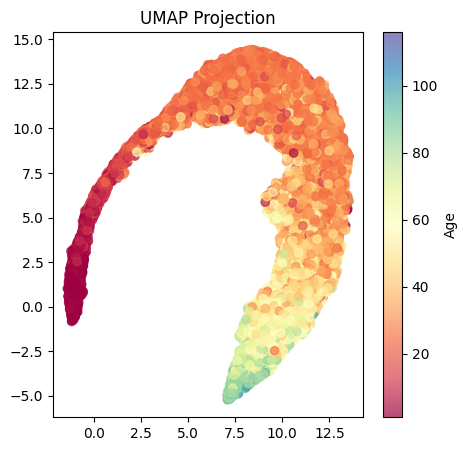

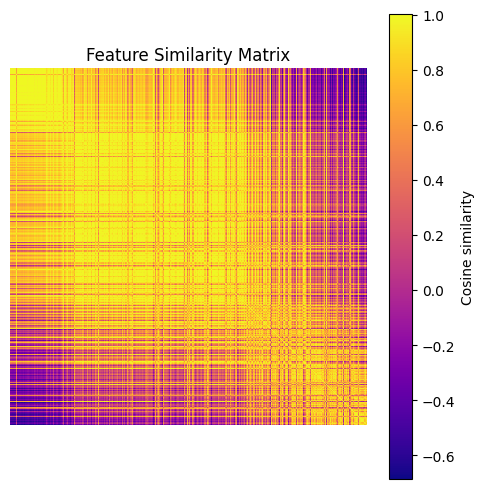

[00:33:25] [INFO] Visualization computed in: 58.70 seconds


In [8]:
start_time = time.time()
visualize({**config, **vis_config}, verbose=verbose)
end_time = time.time()
print_verbose(f"Visualization computed in: {end_time - start_time:.2f} seconds", verbose)